In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

In [2]:

# 1. Eğitim verisini çek (Arkadaşının hazırladığı)
train_df = pd.read_csv("final_train_data.csv")

# 2. Orijinal test verisini çek
test_df = pd.read_csv("test.csv")

# Kaggle teslimatı için PassengerId'yi kenara ayır ve GÜVENDE TUT
test_ids = test_df['PassengerId']

# 1. İsmi Parçalama (Name & Surname) ve Grup Numarasını Çıkarma
test_df[['FirstName', 'Surname']] = test_df['Name'].str.split(' ', expand=True)
test_df['Group'] = test_df['PassengerId'].apply(lambda x: x.split('_')[0])

# 2. Harcamaları Birleştirme (Total_Expense)
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test_df['Total_Expense'] = test_df[expense_cols].sum(axis=1)

# ==========================================
# EKSİK VERİ DOLDURMA (IMPUTATION) İŞLEMLERİ
# ==========================================

# 3. HomePlanet (Ana Gezegen) Doldurma
group_planet = test_df.dropna(subset=['HomePlanet']).groupby('Group')['HomePlanet'].first().to_dict()
test_df['HomePlanet'] = test_df['HomePlanet'].fillna(test_df['Group'].map(group_planet))

surname_planet = test_df.dropna(subset=['HomePlanet']).groupby('Surname')['HomePlanet'].first().to_dict()
test_df['HomePlanet'] = test_df['HomePlanet'].fillna(test_df['Surname'].map(surname_planet))
test_df['HomePlanet'] = test_df['HomePlanet'].fillna('Earth') # Kalan azınlık için Mod

# 4. CryoSleep (Kriyojenik Uyku) Doldurma
test_df.loc[(test_df['CryoSleep'].isnull()) & (test_df['Total_Expense'] > 0), 'CryoSleep'] = False
cabin_cryo_nunique = test_df.dropna(subset=['CryoSleep']).groupby('Cabin')['CryoSleep'].nunique()
pure_cabins = cabin_cryo_nunique[cabin_cryo_nunique == 1].index
cabin_cryo_map = test_df[test_df['Cabin'].isin(pure_cabins)].groupby('Cabin')['CryoSleep'].first().to_dict()
test_df['CryoSleep'] = test_df['CryoSleep'].fillna(test_df['Cabin'].map(cabin_cryo_map))
test_df.loc[(test_df['CryoSleep'].isnull()) & (test_df['Total_Expense'] == 0), 'CryoSleep'] = True
test_df['CryoSleep'] = test_df['CryoSleep'].fillna(False)

# 5. Cabin (Kabin) Doldurma ve Parçalama
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else np.nan

surname_cabin_map = test_df.dropna(subset=['Cabin']).groupby('Surname')['Cabin'].agg(get_mode).to_dict()
test_df['Cabin'] = test_df['Cabin'].fillna(test_df['Surname'].map(surname_cabin_map))
test_df['Cabin'] = test_df['Cabin'].fillna('F/0/S') # Kalan azınlık için Mod

# 6. Destination (Gidilecek Yer) Doldurma
surname_dest_map = test_df.dropna(subset=['Destination']).groupby('Surname')['Destination'].agg(get_mode).to_dict()
test_df['Destination'] = test_df['Destination'].fillna(test_df['Surname'].map(surname_dest_map))
test_df['Destination'] = test_df['Destination'].fillna('TRAPPIST-1e') # Mod

# 7. Age (Yaş) Doldurma
test_df['Age'] = test_df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

# 8. VIP Doldurma
cabin_vip_map = test_df.dropna(subset=['VIP']).groupby('Cabin')['VIP'].agg(lambda x: any(x)).to_dict()
test_df['VIP'] = test_df['VIP'].fillna(test_df['Cabin'].map(cabin_vip_map))
test_df['VIP'] = test_df['VIP'].fillna(False)

# Kabini parçalama
test_df[['Deck', 'Num', 'Side']] = test_df['Cabin'].str.split('/', expand=True)

# 9. Harcama Sütunlarını Doldurma
for col in expense_cols:
    test_df.loc[(test_df['CryoSleep'] == True) & (test_df[col].isnull()), col] = 0
    test_df.loc[(test_df['Age'] < 13) & (test_df[col].isnull()), col] = 0
    test_df[col] = test_df.groupby(['VIP', 'HomePlanet'])[col].transform(lambda x: x.fillna(x.median()))
    test_df[col] = test_df.groupby('VIP')[col].transform(lambda x: x.fillna(x.median()))
    test_df[col] = test_df[col].fillna(test_df[col].median())

# Toplam harcamayı son kez güncelle
test_df['Total_Expense'] = test_df[expense_cols].sum(axis=1)

# Gereksiz sütunları sil
cols_to_drop = [
    'Name', 'FirstName', 'Surname',
    'Cabin', 'PassengerId',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'
]
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')

# ==========================================
# ENCODING VE HİZALAMA (ALIGNMENT)
# ==========================================

# İkilik Dönüşüm (Test setinde Transported YOKTUR!)
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    test_df[col] = test_df[col].astype(int)

test_df['Num'] = test_df['Num'].astype(int)
test_df['Group'] = test_df['Group'].astype(int)

# One-Hot Encoding
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True, dtype=int)

# --- HAYAT KURTARAN HİZALAMA ADIMI ---
# Transported sütununu train'den çıkarıyoruz ki test ile aynı yapıya gelsin
X_train = train_df.drop('Transported', axis=1, errors='ignore')
y_train = train_df['Transported'] # Modeli eğitmek için bunu kullanacaksın

# Sütunları eşitle
X_train, test_df = X_train.align(test_df, join='inner', axis=1)

print(f"Eğitim sütun sayısı: {X_train.shape[1]}")
print(f"Test sütun sayısı: {test_df.shape[1]}")
print("Tebrikler, test verisi modelleme için %100 hazır!")

C:\Users\Asus\AppData\Local\Temp\ipykernel_51592\958684088.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['CryoSleep'] = test_df['CryoSleep'].fillna(False)


Eğitim sütun sayısı: 18
Test sütun sayısı: 18
Tebrikler, test verisi modelleme için %100 hazır!


C:\Users\Asus\AppData\Local\Temp\ipykernel_51592\958684088.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['VIP'] = test_df['VIP'].fillna(False)


In [3]:
import pandas as pd
import time
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler


# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


Model Adı                 | Süre (Sn)  | Doğruluk   | F1 Skor
-----------------------------------------------------------------
Logistic Regression       | 0.024      | 0.743      | 0.719
Naive Bayes               | 0.005      | 0.732      | 0.713
Decision Tree             | 0.016      | 0.765      | 0.745
Random Forest             | 0.393      | 0.745      | 0.717
XGBoost                   | 0.254      | 0.790      | 0.771
LightGBM                  | 2.469      | 0.792      | 0.772
CatBoost                  | 0.841      | 0.819      | 0.807


C:\Users\Asus\AppData\Local\Temp\ipykernel_51592\3335172393.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Doğruluk", y="Model", data=sonuclar_df, palette="viridis")


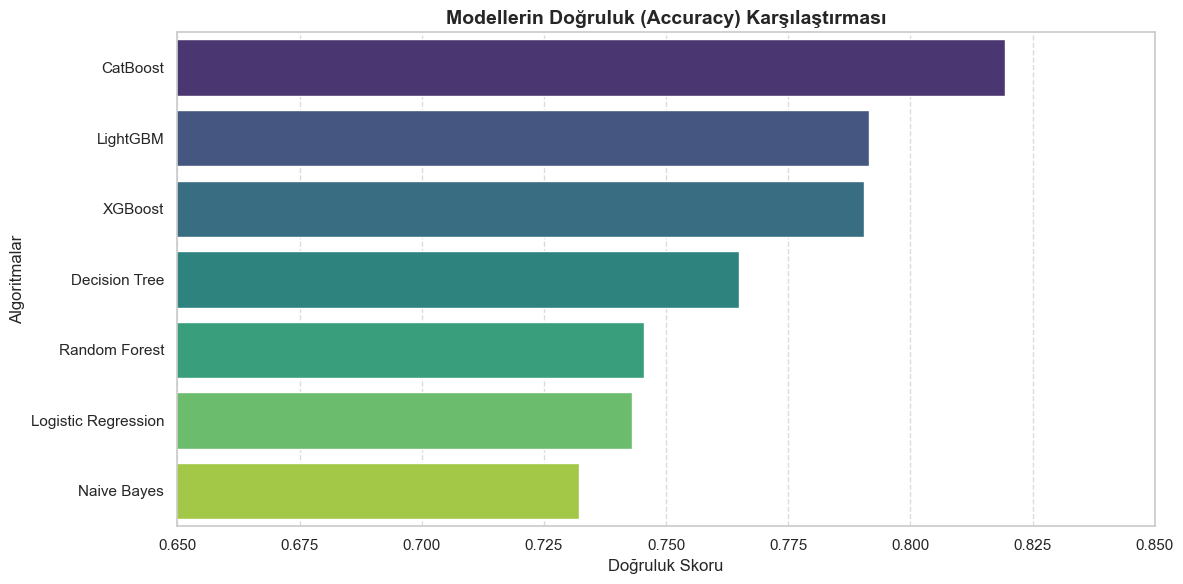

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Scaler'ı tanımla
scaler = StandardScaler()

# 2. Eğitim verimizi ölçeklendir (Hem öğrenip hem dönüştürüyor)
X_train_scaled = scaler.fit_transform(X_train)

# (İpucu: Kaggle'a göndereceğimiz test_df'i de AYNI scaler ile dönüştürmeliyiz)
# Sadece transform yapıyoruz ki eğitimdeki oranları kullansın, test verisinden kopya çekmesin
test_df_scaled = scaler.transform(test_df)

# 3. ŞİMDİ veriyi eğitim ve doğrulama olarak ayır (Artık X_train_scaled kullanıyoruz)
X_egitim, X_val, y_egitim, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
modeller = {
    "Logistic Regression": LogisticRegression(solver='liblinear',max_iter=1000,random_state=42),
    "Naive Bayes": GaussianNB(),

    # EZBERİ BOZULAN MODELLER:
    # max_depth ile ağacın derinliğini kısıtlıyoruz (buduyoruz)
    # min_samples_split ile bir dalın ayrılması için en az 10 kişi olmasını şart koşuyoruz
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, random_state=42),

    # Eski GridSearch çalışmanda bulduğun şampiyon parametreleri buraya entegre ettik
    "XGBoost": XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(max_depth=4, learning_rate=0.1, n_estimators=100, random_state=42, verbose=-1),
   "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, random_state=42, verbose=False)



}

sonuclar = []

print(f"{'Model Adı':<25} | {'Süre (Sn)':<10} | {'Doğruluk':<10} | {'F1 Skor'}")
print("-" * 65)

for isim, model in modeller.items():
    baslangic = time.time()

    model.fit(X_train, y_train)
    tahmin = model.predict(X_val)

    sure = time.time() - baslangic
    acc = accuracy_score(y_val, tahmin)
    f1 = f1_score(y_val, tahmin)

    sonuclar.append({"Model": isim, "Doğruluk": acc, "F1 Skor": f1})
    print(f"{isim:<25} | {sure:<10.3f} | {acc:<10.3f} | {f1:.3f}")

# Sonuçları Grafiğe Dökme
sonuclar_df = pd.DataFrame(sonuclar).sort_values(by="Doğruluk", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Doğruluk", y="Model", data=sonuclar_df, palette="viridis")
plt.title("Modellerin Doğruluk (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold')
plt.xlabel("Doğruluk Skoru", fontsize=12)
plt.ylabel("Algoritmalar", fontsize=12)
plt.xlim(0.65, 0.85) # Farkı daha net görmek için x eksenini daraltıyoruz
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

elimizeki modellerden ağır olanlar normal olarak yükseldi. Catboost fark bile açtı. bundan daha ileri gitmemiz lazım şimdi. iki yolumuz var.
* Modelleri geliştirmek ve ya değiştirmek
* Veriyle oynamak

Önce model eklemeleri yapalım. Yapay sinir ağları kullanmak mantıklı bir seçenek olmaz. Çünkü salt veriyle uğraşıyoruz ve yapay sinir ağları bu konuda o kadar da başarılı değil. Yine de deneyelim.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. X (Özellikler) ve y (Hedef) Değişkenlerini Ayırma
# train_df'in daha önceki adımlarda (One-Hot Encoding vb.) hazırlandığını varsayıyoruz
X = train_df.drop('Transported', axis=1)
y = train_df['Transported'].astype(int) # True/False değerlerini 1 ve 0'a çeviriyoruz

# 2. Veriyi Eğitim (Train) ve Doğrulama (Validation) Olarak Bölme
X_egitim, X_val, y_egitim, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Ölçeklendirme (Scaling) İşlemi
scaler = StandardScaler()

# DİKKAT: Veri sızıntısını (Data Leakage) önlemek için fit_transform SADECE eğitim verisine uygulanır!
X_egitim_scaled = scaler.fit_transform(X_egitim)

# Validation verisine ise sadece eğitim verisinden öğrenilen kurallar (transform) uygulanır
X_val_scaled = scaler.transform(X_val)

print("✅ Veriler başarıyla bölündü ve sinir ağları için ölçeklendirildi!")

✅ Veriler başarıyla bölündü ve sinir ağları için ölçeklendirildi!


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

print("🧠 Yapay Sinir Ağı (ANN) Eğitiliyor...")
baslangic = time.time()

# Modeli tanımlıyoruz
# hidden_layer_sizes=(100, 50): İlk katmanda 100, ikinci katmanda 50 nöron (hücre) var
ann_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500, # Maksimum deneme sayısı
    activation='relu', # Sinir ağlarının en sevdiği aktivasyon fonksiyonu
    solver='adam', # Ağırlıkları güncelleyen motor
    random_state=42
)

# DİKKAT: Sinir ağları ölçeklenmemiş veriden nefret eder.
# Bu yüzden X_egitim_scaled kullanıyoruz!
ann_model.fit(X_egitim_scaled, y_egitim)

# Validation setinde test ediyoruz
ann_tahmin = ann_model.predict(X_val_scaled)
ann_acc = accuracy_score(y_val, ann_tahmin)

sure = time.time() - baslangic

print("-" * 50)
print(f"✅ Eğitim Tamamlandı! Süre: {sure:.2f} saniye")
print(f"📊 Yapay Sinir Ağı (ANN) Lokal Doğruluk Skoru: {ann_acc:.4f}")
print("-" * 50)

🧠 Yapay Sinir Ağı (ANN) Eğitiliyor...
--------------------------------------------------
✅ Eğitim Tamamlandı! Süre: 8.69 saniye
📊 Yapay Sinir Ağı (ANN) Lokal Doğruluk Skoru: 0.7258
--------------------------------------------------


hem yavaş hem de naive bayesten bile düşük. Uğraşmaya değmez. Şimdi LLM deneme zamanı

In [7]:
from transformers import pipeline

print("🧠 Hugging Face LLM Sınıflandırıcısı Yükleniyor... (Birkaç saniye sürebilir)\n")

# facebook/bart-large-mnli modeli metinleri okuyup verdiğimiz etiketlere göre sınıflandırmada uzmandır
llm_tahminci = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 1. Verimizi LLM'in anlayacağı bir "Hikayeye" çeviriyoruz
# (Bunu gerçek projede bir for döngüsü ile binlerce yolcu için otomatik yapabiliriz)
yolcu_profili = "Bu yolcu Europa gezegeninden geliyor, zengin biri, VIP güvertesinde seyahat ediyor. Ancak kriyojenik uykuya yatmamış ve gemide çok fazla para harcamış."

# 2. LLM'in seçmesi gereken etiketler (Transported: True veya False durumu)
olasi_sonuclar = [
    "Bu yolcu uzay-zaman anomalisine kapılıp taşınmıştır.",
    "Bu yolcu gemide kalmış ve taşınmamıştır."
]

# 3. Modele soruyoruz
print("🕵️ LLM Düşünüyor...\n")
sonuc = llm_tahminci(yolcu_profili, candidate_labels=olasi_sonuclar)

# Sonuçları yazdırma
print(f"📖 Yolcu Özeti: {yolcu_profili}")
print("-" * 50)
print(f"🥇 LLM'in En Güçlü Tahmini: {sonuc['labels'][0]}")
print(f"🎯 Eminlik Oranı: % {sonuc['scores'][0] * 100:.2f}")

🧠 Hugging Face LLM Sınıflandırıcısı Yükleniyor... (Birkaç saniye sürebilir)



Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

🕵️ LLM Düşünüyor...

📖 Yolcu Özeti: Bu yolcu Europa gezegeninden geliyor, zengin biri, VIP güvertesinde seyahat ediyor. Ancak kriyojenik uykuya yatmamış ve gemide çok fazla para harcamış.
--------------------------------------------------
🥇 LLM'in En Güçlü Tahmini: Bu yolcu uzay-zaman anomalisine kapılıp taşınmıştır.
🎯 Eminlik Oranı: % 71.23


Şimdi bu ne diye sorabilirsiniz. tek bir yolcunun kurtulup kurtulmaması verisi. Sadece bunu bulması bile 4 dakika sürde ve eminlik skoru 71.23%. yani tüm satırları tek tek okuması çok uzun sürer. denemiş olduk ama.

🔍 Kör Nokta Analizi (Error Analysis) Başlıyor...

🧠 Modeller analiz için hızlıca eğitiliyor...


C:\Users\Asus\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🌟 Aydınlık Bölge (Üçü de Doğru): 1203 yolcu
🌫️ Gri Bölge (Kararsızlar): 220 yolcu
🌑 Karanlık Bölge (Üçü de Yanlış - KÖR NOKTA): 309 yolcu

🕵️ ÖRÜNTÜ ANALİZİ: Modeller Hangi Profili Anlayamıyor?

               Başarılı Profil (Aydınlık)  Çuvalladığımız Profil (Karanlık)
Age                                 29.11                             28.24
Total_Expense                     1242.06                           1857.81
CryoSleep                            0.39                              0.29
--------------------------------------------------


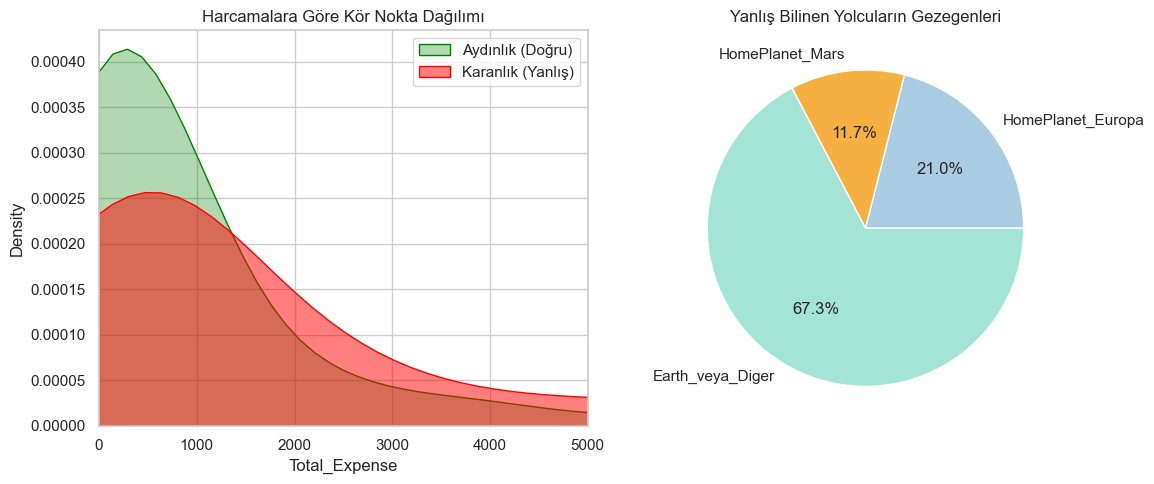

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("🔍 Kör Nokta Analizi (Error Analysis) Başlıyor...\n")

# ==========================================
# 0. MODELLERİ HAZIRLAMA (NameError ve NotFittedError Önlemi)
# ==========================================
print("🧠 Modeller analiz için hızlıca eğitiliyor...")
model_cat = CatBoostClassifier(random_state=42, verbose=False)
model_lgb = LGBMClassifier(random_state=42, verbose=-1)
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

model_cat.fit(X_egitim_scaled, y_egitim)
model_lgb.fit(X_egitim_scaled, y_egitim)
model_xgb.fit(X_egitim_scaled, y_egitim)

# ==========================================
# 1. TAHMİNLERİ ALMA VE TABLOYU KURMA
# ==========================================
tahmin_cat = model_cat.predict(X_val_scaled)
tahmin_lgb = model_lgb.predict(X_val_scaled)
tahmin_xgb = model_xgb.predict(X_val_scaled)

# Yorumlanabilirlik için ölçeklenmemiş orijinal X_val verisini kopyalayalım
analiz_df = X_val.copy()
analiz_df['Gercek_Sonuc'] = y_val.values

# Modellerin tahminlerini ekleyelim
analiz_df['Cat_Tahmin'] = tahmin_cat
analiz_df['Lgb_Tahmin'] = tahmin_lgb
analiz_df['Xgb_Tahmin'] = tahmin_xgb

# Doğruluk kontrolü (1=Doğru Bildi, 0=Yanlış Bildi)
analiz_df['Cat_Dogru'] = (analiz_df['Cat_Tahmin'] == analiz_df['Gercek_Sonuc']).astype(int)
analiz_df['Lgb_Dogru'] = (analiz_df['Lgb_Tahmin'] == analiz_df['Gercek_Sonuc']).astype(int)
analiz_df['Xgb_Dogru'] = (analiz_df['Xgb_Tahmin'] == analiz_df['Gercek_Sonuc']).astype(int)

# UZLAŞMA SKORU: Her satır için kaç model doğru bildi? (0, 1, 2 veya 3)
analiz_df['Konsey_Skoru'] = analiz_df['Cat_Dogru'] + analiz_df['Lgb_Dogru'] + analiz_df['Xgb_Dogru']

# ==========================================
# 2. VERİYİ 3 ANA BÖLGEYE AYIRMA
# ==========================================
aydinlik_bolge = analiz_df[analiz_df['Konsey_Skoru'] == 3] # 3 dev model de %100 Emin ve Doğru
gri_bolge = analiz_df[(analiz_df['Konsey_Skoru'] == 1) | (analiz_df['Konsey_Skoru'] == 2)] # Modeller anlaşamıyor
karanlik_bolge = analiz_df[analiz_df['Konsey_Skoru'] == 0] # 3 model de KESİNLİKLE YANLIŞ bildi! (Kör Noktamız)

print(f"🌟 Aydınlık Bölge (Üçü de Doğru): {len(aydinlik_bolge)} yolcu")
print(f"🌫️ Gri Bölge (Kararsızlar): {len(gri_bolge)} yolcu")
print(f"🌑 Karanlık Bölge (Üçü de Yanlış - KÖR NOKTA): {len(karanlik_bolge)} yolcu\n")

# ==========================================
# 3. ÖRÜNTÜ AVI: KARANLIK BÖLGE VS AYDINLIK BÖLGE
# ==========================================
print("🕵️ ÖRÜNTÜ ANALİZİ: Modeller Hangi Profili Anlayamıyor?\n")

kiyaslama_sutunlari = ['Age', 'Total_Expense', 'CryoSleep']

karsilastirma_tablosu = pd.DataFrame({
    "Başarılı Profil (Aydınlık)": aydinlik_bolge[kiyaslama_sutunlari].mean(),
    "Çuvalladığımız Profil (Karanlık)": karanlik_bolge[kiyaslama_sutunlari].mean()
}).round(2)

print(karsilastirma_tablosu)
print("-" * 50)

# ==========================================
# 4. KÖR NOKTANIN GÖRSEL RÖNTGENİ
# ==========================================
if 'HomePlanet_Europa' in karanlik_bolge.columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.kdeplot(aydinlik_bolge['Total_Expense'], label='Aydınlık (Doğru)', fill=True, color='green', alpha=0.3)
    sns.kdeplot(karanlik_bolge['Total_Expense'], label='Karanlık (Yanlış)', fill=True, color='red', alpha=0.5)
    plt.title("Harcamalara Göre Kör Nokta Dağılımı")
    plt.xlim(0, 5000)
    plt.legend()

    plt.subplot(1, 2, 2)
    gezegen_toplamlari = karanlik_bolge[['HomePlanet_Europa', 'HomePlanet_Mars']].sum()
    gezegen_toplamlari['Earth_veya_Diger'] = len(karanlik_bolge) - gezegen_toplamlari.sum()
    gezegen_toplamlari.plot(kind='pie', autopct='%1.1f%%', colors=['#A9CCE3', '#F5B041', '#A3E4D7'])
    plt.title("Yanlış Bilinen Yolcuların Gezegenleri")
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 4. TAKTİK İÇİN YENİ SİLAHIMIZ: StackingClassifier ve LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("🛠️ 'Oyun Sonu' (Endgame) Taktikleri Başlıyor...\n")

# Verileri en ham halleriyle yüklüyoruz
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Hedef değişkeni ayırıp eğitim ve test setini birleştiriyoruz (İşlemleri tek seferde yapmak için)
y = train_df['Transported'].astype(int)
train_df.drop('Transported', axis=1, inplace=True)

tum_veri = pd.concat([train_df, test_df], ignore_index=True)
harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# ==========================================
# TAKTİK 1: Aile/Grup Sırrı (PassengerId'den)
# ==========================================
# PassengerId formatı: GGGG_PP. Split ile '_' karakterinden bölüp ilk kısmı (Grubu) alıyoruz
tum_veri['Grup'] = tum_veri['PassengerId'].apply(lambda x: x.split('_')[0])

# Her grupta kaç kişi olduğunu sayıp yeni bir sütuna yazıyoruz
grup_sayilari = tum_veri['Grup'].value_counts().to_dict()
tum_veri['Grup_Boyutu'] = tum_veri['Grup'].map(grup_sayilari)

print("✅ Taktik 1: 'Grup_Boyutu' başarıyla çıkarıldı!")

# ==========================================
# TAKTİK 2: Sherlock Holmes (Mantıksal Doldurma)
# ==========================================
# Önce toplam harcamayı bulalım
tum_veri['Total_Expense'] = tum_veri[harcama_sutunlari].sum(axis=1)

# Mantık A: Harcaması 0'dan büyükse KESİNLİKLE uyumuyordur (CryoSleep = False)
tum_veri.loc[(tum_veri['Total_Expense'] > 0) & (tum_veri['CryoSleep'].isnull()), 'CryoSleep'] = False

# Mantık B: Kriyojenik uykudaysa KESİNLİKLE harcaması 0'dır
for col in harcama_sutunlari:
    tum_veri.loc[(tum_veri['CryoSleep'] == True) & (tum_veri[col].isnull()), col] = 0

print("✅ Taktik 2: CryoSleep ve Harcama boşlukları mantıkla dolduruldu!")

# ==========================================
# TAKTİK 3: Gemi Topografyası (Kabin Bölgesi)
# ==========================================
# Cabin sütununu Deck (Güverte), Num (Numara) ve Side (Taraf) olarak 3'e bölüyoruz
tum_veri[['Deck', 'Num', 'Side']] = tum_veri['Cabin'].str.split('/', expand=True)

# Kabin numarasını sayıya çeviriyoruz
tum_veri['Num'] = pd.to_numeric(tum_veri['Num'], errors='coerce')

# Gemiyi 300'lük bloklar halinde "Bölgelere" ayırıyoruz
tum_veri['Gemi_Bolgesi'] = pd.cut(tum_veri['Num'],
                                  bins=[-1, 300, 600, 900, 1200, 1500, 2000],
                                  labels=['Bolge_1', 'Bolge_2', 'Bolge_3', 'Bolge_4', 'Bolge_5', 'Bolge_6'])

print("✅ Taktik 3: Kabin numaralarından 'Gemi_Bolgesi' oluşturuldu!")

# ==========================================
# ESKİ GÜÇLÜ SİLAHLARIMIZI DA EKLİYORUZ
# ==========================================
tum_veri['Expenditure_Type'] = pd.cut(tum_veri['Total_Expense'],
                                      bins=[-1, 1, 1000, 100000],
                                      labels=['No_Spend', 'Medium_Spend', 'High_Spend'])

tum_veri['VIP_Deck'] = tum_veri['Deck'].apply(lambda x: 1 if x in ['B', 'C'] else 0)

# ==========================================
# VERİ TEMİZLİĞİ VE SAYISALLAŞTIRMA
# ==========================================
# Artık işi biten kalabalık sütunları atıyoruz
dusulecek_sutunlar = ['PassengerId', 'Cabin', 'Name', 'Grup', 'Num']
tum_veri.drop(columns=dusulecek_sutunlar, inplace=True)

# Kalan tüm metinleri sayılara çeviriyoruz (One-Hot Encoding)
tum_veri = pd.get_dummies(tum_veri, drop_first=True)

# Eğitim ve test setini tekrar ayırıyoruz
X_train_full = tum_veri.iloc[:len(train_df)]
X_test_final = tum_veri.iloc[len(train_df):]

# Modeli test etmek için kendi içimizde train/val olarak bölüyoruz
X_egitim, X_val, y_egitim, y_val = train_test_split(X_train_full, y, test_size=0.2, random_state=42)

# ==========================================
# TAKTİK 4: STACKING (KURMAY ZEKASI) KURULUMU
# ==========================================
print("\n🧠 Modeller Eğitiliyor ve Kurmay Zekası (Stacking) Kuruluyor...")
print("Bu işlem modellerin detaylı analizinden dolayı 1-2 dakika sürebilir...\n")

# Temel askerlerimiz (Base Estimators)
cat = CatBoostClassifier(random_state=42, verbose=False)
lgb = LGBMClassifier(random_state=42, verbose=-1)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Kurmay Modelimiz (Meta Model - Logistic Regression)
# Bu model, aşağıdaki 3 devin yaptığı tahminleri alıp kimin nerede haklı olduğunu öğrenecek!
meta_model = LogisticRegression()

kurmay_sistemi = StackingClassifier(
    estimators=[('cat', cat), ('lgb', lgb), ('xgb', xgb)],
    final_estimator=meta_model,
    cv=5 # Modellerin zafiyetlerini öğrenmek için 5 çapraz doğrulama yapar
)

# Kurmay sistemini eğitiyoruz
kurmay_sistemi.fit(X_egitim, y_egitim)

# ==========================================
# FİNAL SKORLARI
# ==========================================
print("="*50)
print("🏆 OYUN SONU (ENDGAME) SKORLARI")
print("="*50)
print(f"Eski Voting Konseyi Skoru Genelde: ~0.80 - 0.81")
print(f"🚀 YENİ STACKING KURMAY SKORU: {accuracy_score(y_val, kurmay_sistemi.predict(X_val)):.4f}")
print("="*50)

🛠️ 'Oyun Sonu' (Endgame) Taktikleri Başlıyor...

✅ Taktik 1: 'Grup_Boyutu' başarıyla çıkarıldı!
✅ Taktik 2: CryoSleep ve Harcama boşlukları mantıkla dolduruldu!
✅ Taktik 3: Kabin numaralarından 'Gemi_Bolgesi' oluşturuldu!

🧠 Modeller Eğitiliyor ve Kurmay Zekası (Stacking) Kuruluyor...
Bu işlem modellerin detaylı analizinden dolayı 1-2 dakika sürebilir...

🏆 OYUN SONU (ENDGAME) SKORLARI
Eski Voting Konseyi Skoru Genelde: ~0.80 - 0.81
🚀 YENİ STACKING KURMAY SKORU: 0.8108


📊 Grafikler Hazırlanıyor...


C:\Users\Asus\AppData\Local\Temp\ipykernel_51592\739002437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Grup_Boyutu', y='Transported', palette='viridis', ax=axes[0, 0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_51592\739002437.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Gemi_Bolgesi', y='Transported', palette='magma', ax=axes[0, 1])


CatBoostError: There is no trained model to use predict(). Use fit() to train model. Then use this method.

C:\Users\Asus\miniconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\Asus\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


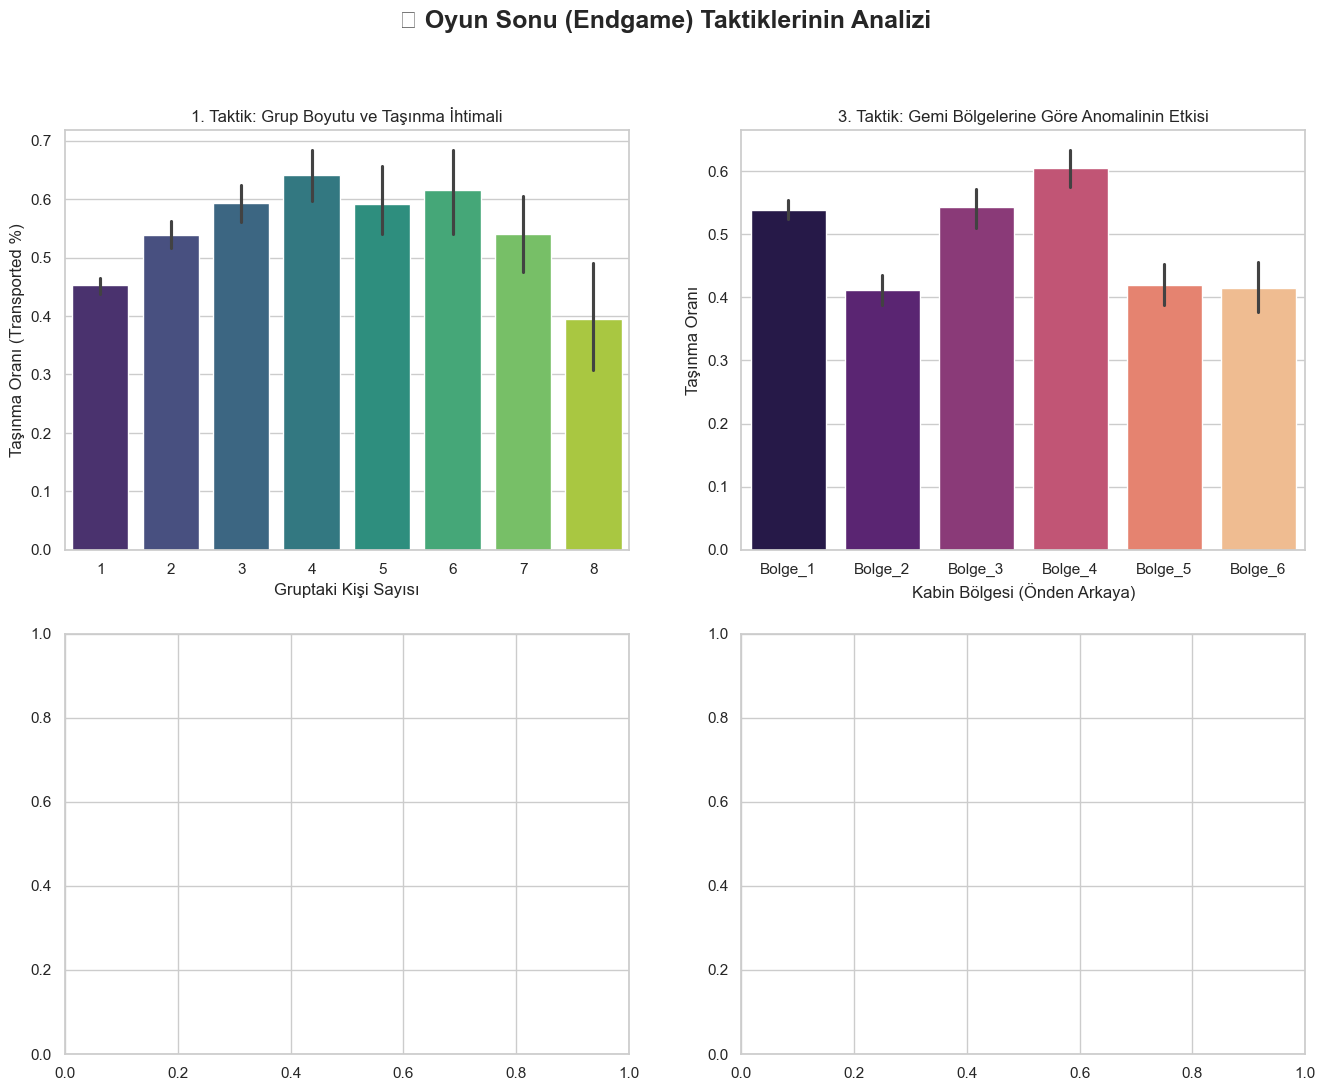

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

print("📊 Grafikler Hazırlanıyor...")

# 1. GRAFİKLER İÇİN ÖZEL VERİ HAZIRLIĞI (Model verisini bozmamak için)
plot_df = pd.read_csv("train.csv")

# Grup boyutunu tekrar çıkaralım
plot_df['Grup'] = plot_df['PassengerId'].apply(lambda x: x.split('_')[0])
plot_df['Grup_Boyutu'] = plot_df['Grup'].map(plot_df['Grup'].value_counts().to_dict())

# Gemi bölgesini tekrar çıkaralım
plot_df[['Deck', 'Num', 'Side']] = plot_df['Cabin'].str.split('/', expand=True)
plot_df['Num'] = pd.to_numeric(plot_df['Num'], errors='coerce')
plot_df['Gemi_Bolgesi'] = pd.cut(plot_df['Num'],
                                  bins=[-1, 300, 600, 900, 1200, 1500, 2000],
                                  labels=['Bolge_1', 'Bolge_2', 'Bolge_3', 'Bolge_4', 'Bolge_5', 'Bolge_6'])

# 2. GRAFİK ÇİZİMİ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("🚀 Oyun Sonu (Endgame) Taktiklerinin Analizi", fontsize=18, fontweight='bold')

# Grafik 1: Aile Sırrı (Grup Boyutu ve Taşınma Oranı)
sns.barplot(data=plot_df, x='Grup_Boyutu', y='Transported', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title("1. Taktik: Grup Boyutu ve Taşınma İhtimali", fontsize=12)
axes[0, 0].set_ylabel("Taşınma Oranı (Transported %)")
axes[0, 0].set_xlabel("Gruptaki Kişi Sayısı")

# Grafik 2: Gemi Topografyası (Kabin Bölgesi)
sns.barplot(data=plot_df, x='Gemi_Bolgesi', y='Transported', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title("3. Taktik: Gemi Bölgelerine Göre Anomalinin Etkisi", fontsize=12)
axes[0, 1].set_ylabel("Taşınma Oranı")
axes[0, 1].set_xlabel("Kabin Bölgesi (Önden Arkaya)")

# Grafik 3: Modellerin Kapışması (Hafızadaki modellerin skorları)
try:
    skorlar = {
        'CatBoost': accuracy_score(y_val, cat.predict(X_val)),
        'LightGBM': accuracy_score(y_val, lgb.predict(X_val)),
        'XGBoost': accuracy_score(y_val, xgb.predict(X_val)),
        'Stacking (Kurmay)': accuracy_score(y_val, kurmay_sistemi.predict(X_val))
    }

    sns.barplot(x=list(skorlar.keys()), y=list(skorlar.values()), palette=['#A9CCE3', '#A9CCE3', '#A9CCE3', '#E74C3C'], ax=axes[1, 0])
    axes[1, 0].set_title("4. Taktik: Modellerin Doğruluk (Accuracy) Yarışı", fontsize=12)
    axes[1, 0].set_ylim(0.70, 0.85) # Farkı net görmek için alt sınırı 0.70 yaptık

    # Barların üstüne sayıları yazdırma
    for i, v in enumerate(skorlar.values()):
        axes[1, 0].text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
except NameError:
    axes[1, 0].text(0.5, 0.5, "Modeller hafızada bulunamadı.\nLütfen önce eğitim hücresini çalıştırın.",
                    ha='center', va='center', fontsize=12)
    axes[1, 0].set_title("Modellerin Kapışması")

# Boş kalan 4. paneli gizleyelim
axes[1, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [11]:
qprint("🚀 Final Kaggle Dosyası Hazırlanıyor...\n")

# 1. TEST VERİSİNİN SÜTUNLARINI EŞİTLEME
# Modelin eğitildiği sütun sırasıyla test verisinin sırası birebir aynı olmalı
X_test_final = X_test_final[X_egitim.columns]

# 2. KURMAY SİSTEMİ (STACKING) İLE TAHMİN YAPMA
# Eğittiğimiz en güçlü model olan 'kurmay_sistemi' ile test verisi üzerinde tahminleri alıyoruz
# (0 ve 1 olarak sonuç dönecektir)
final_tahminler = kurmay_sistemi.predict(X_test_final)

# 3. KAGLE FORMATINA DÖNÜŞTÜRME (1/0 -> True/False)
# Kaggle bu yarışmada sonuçların Boolean (True/False) olmasını ister
final_tahminler_bool = [True if val == 1 else False for val in final_tahminler]

# 4. YÜKLEME (SUBMISSION) DOSYASINI OLUŞTURMA
# Orijinal test.csv'deki PassengerId'leri alıp tahminlerle birleştiriyoruz
orijinal_test = pd.read_csv("test.csv")

submission_df = pd.DataFrame({
    'PassengerId': orijinal_test['PassengerId'],
    'Transported': final_tahminler_bool
})

# 5. CSV OLARAK KAYDETME
dosya_adi = "submission_endgame_stacking.csv"
submission_df.to_csv(dosya_adi, index=False)

print(f"✅ TEBRİKLER! '{dosya_adi}' dosyası başarıyla oluşturuldu.")
print("Şimdi bu dosyayı Kaggle'a yükleyip o meşhur 'Özellik Duvarı'nı yıkıp yıkmadığını görebilirsin!")

🚀 Final Kaggle Dosyası Hazırlanıyor...

✅ TEBRİKLER! 'submission_endgame_stacking.csv' dosyası başarıyla oluşturuldu.
Şimdi bu dosyayı Kaggle'a yükleyip o meşhur 'Özellik Duvarı'nı yıkıp yıkmadığını görebilirsin!
